# Notebook 3 — KMeans Clustering, Tuning & Test Predictions

With clean, scaled, and reduced data ready, we now build and evaluate a KMeans clustering model, find the optimal number of clusters, and run predictions on the test set.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

sns.set_style('darkgrid')

df = pd.read_csv('../data/train_processed.csv')
print('Loaded processed data:', df.shape)
df.head(3)

Loaded processed data: (22660, 16)


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,PC11,PC12,PC13,PC14,genre,topic
0,-1.398076,-1.278981,-0.571528,-0.507212,-0.674995,-1.900005,-0.079108,0.742477,1.194157,1.014177,1.389519,-0.570283,-0.165900,2.002926,pop,sadness
1,-1.699970,1.906363,1.841023,1.233175,-0.123971,0.273687,-0.254658,-1.146926,0.008897,-0.951868,0.219816,-0.621364,0.584668,1.604556,pop,world/life
2,-2.697900,-1.218182,0.935964,0.132908,0.895386,-2.600580,1.882863,0.091561,3.695177,2.844402,0.141254,0.058905,0.374594,0.876427,pop,music


In [2]:
# separate feature columns from reference columns
feature_cols = [col for col in df.columns if col.startswith('PC')]
X = df[feature_cols].values
print('Feature matrix shape:', X.shape)

Feature matrix shape: (22660, 14)


## Finding the Optimal Number of Clusters

We use two methods together — the **Elbow Method** (inertia) and the **Silhouette Score** — to pick the best k.

In [3]:
inertias = []
silhouette_scores = []
k_range = range(2, 12)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X)
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X, labels, sample_size=5000, random_state=42))
    print(f'k={k} | Inertia: {km.inertia_:.0f} | Silhouette: {silhouette_score(X, labels, sample_size=5000, random_state=42):.4f}')

k=2 | Inertia: 323445 | Silhouette: 0.0946
k=3 | Inertia: 299589 | Silhouette: 0.0995
k=4 | Inertia: 279766 | Silhouette: 0.1181
k=5 | Inertia: 264409 | Silhouette: 0.1329
k=6 | Inertia: 245981 | Silhouette: 0.1531
k=7 | Inertia: 235670 | Silhouette: 0.1543
k=8 | Inertia: 221817 | Silhouette: 0.1649
k=9 | Inertia: 213280 | Silhouette: 0.1641
k=10 | Inertia: 206139 | Silhouette: 0.1587
k=11 | Inertia: 198105 | Silhouette: 0.1617


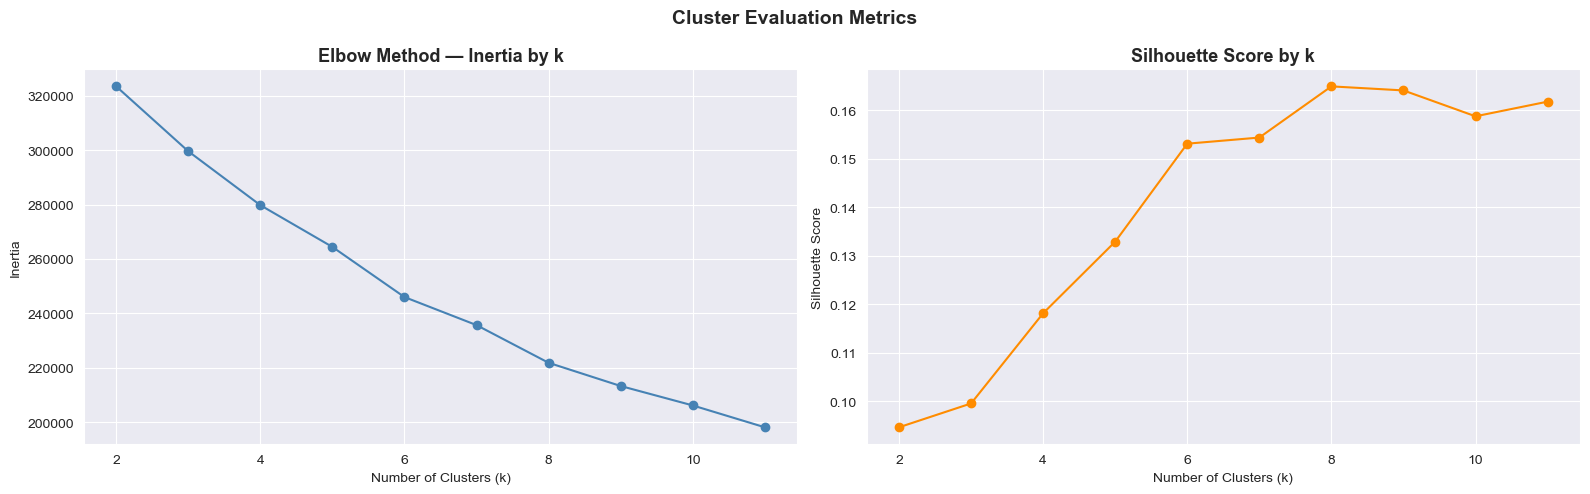

In [4]:
# plot both metrics side by side
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# elbow curve
axes[0].plot(list(k_range), inertias, marker='o', color='steelblue')
axes[0].set_title('Elbow Method — Inertia by k', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')

# silhouette scores
axes[1].plot(list(k_range), silhouette_scores, marker='o', color='darkorange')
axes[1].set_title('Silhouette Score by k', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('Cluster Evaluation Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [5]:
# pick optimal k based on elbow + highest silhouette
best_k = list(k_range)[np.argmax(silhouette_scores)]
print(f'Best k by silhouette score: {best_k}')
print(f'Silhouette score at k={best_k}: {max(silhouette_scores):.4f}')

Best k by silhouette score: 8
Silhouette score at k=8: 0.1649


## Train Final KMeans Model

In [6]:
# train final model with best k
kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X)

print('Cluster label distribution:')
print(df['cluster'].value_counts().sort_index())

Cluster label distribution:
cluster
0    4026
1    3834
2    4403
3    1301
4    1732
5    4508
6    1524
7    1332
Name: count, dtype: int64


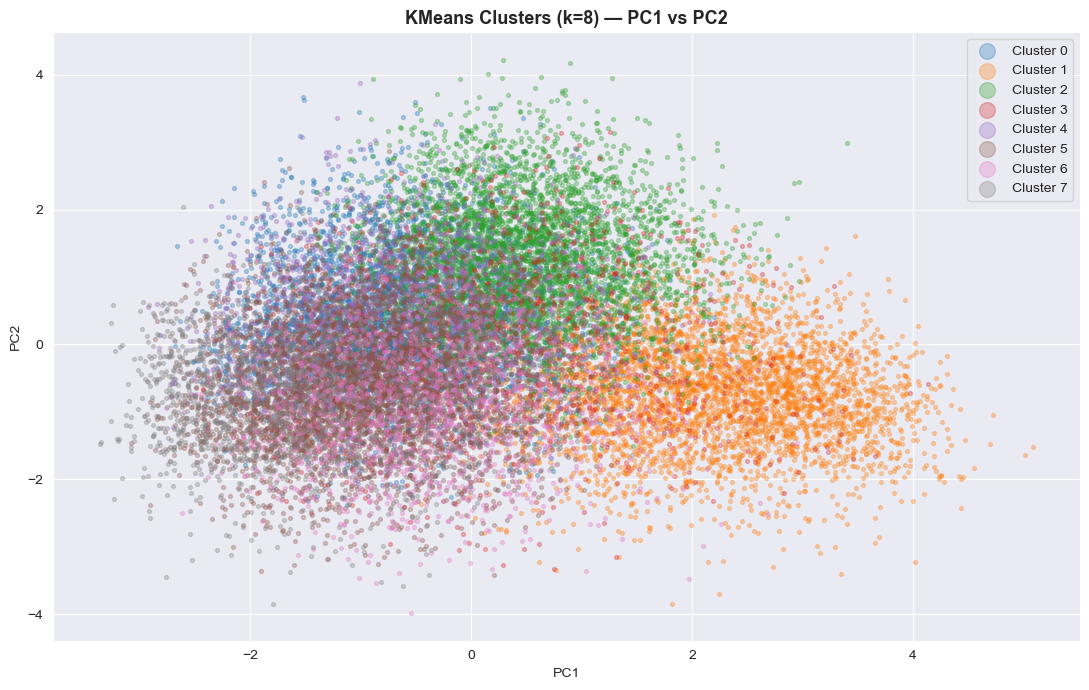

In [7]:
# visualize clusters on first two PCA components
fig, ax = plt.subplots(figsize=(11, 7))
palette = sns.color_palette('tab10', best_k)

for cluster_id in sorted(df['cluster'].unique()):
    subset = df[df['cluster'] == cluster_id]
    ax.scatter(subset['PC1'], subset['PC2'], alpha=0.3, s=8,
               color=palette[cluster_id], label=f'Cluster {cluster_id}')

ax.set_title(f'KMeans Clusters (k={best_k}) — PC1 vs PC2', fontsize=13, fontweight='bold')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

In [8]:
# genre composition of each cluster — useful for the report
cluster_genre = pd.crosstab(df['cluster'], df['genre'], normalize='index').round(3)
print('Genre distribution within each cluster:')
cluster_genre

Genre distribution within each cluster:


genre,blues,country,hip hop,jazz,pop,reggae,rock
cluster,,,,,,,
0,0.127,0.212,0.008,0.141,0.258,0.102,0.152
1,0.106,0.117,0.159,0.139,0.250,0.152,0.078
2,0.186,0.115,0.019,0.120,0.224,0.097,0.238
3,0.209,0.261,0.021,0.098,0.200,0.108,0.104
4,0.185,0.259,0.006,0.170,0.218,0.058,0.103
5,0.144,0.262,0.006,0.110,0.277,0.046,0.155
6,0.173,0.222,0.005,0.112,0.261,0.076,0.150
7,0.167,0.252,0.003,0.180,0.273,0.033,0.091


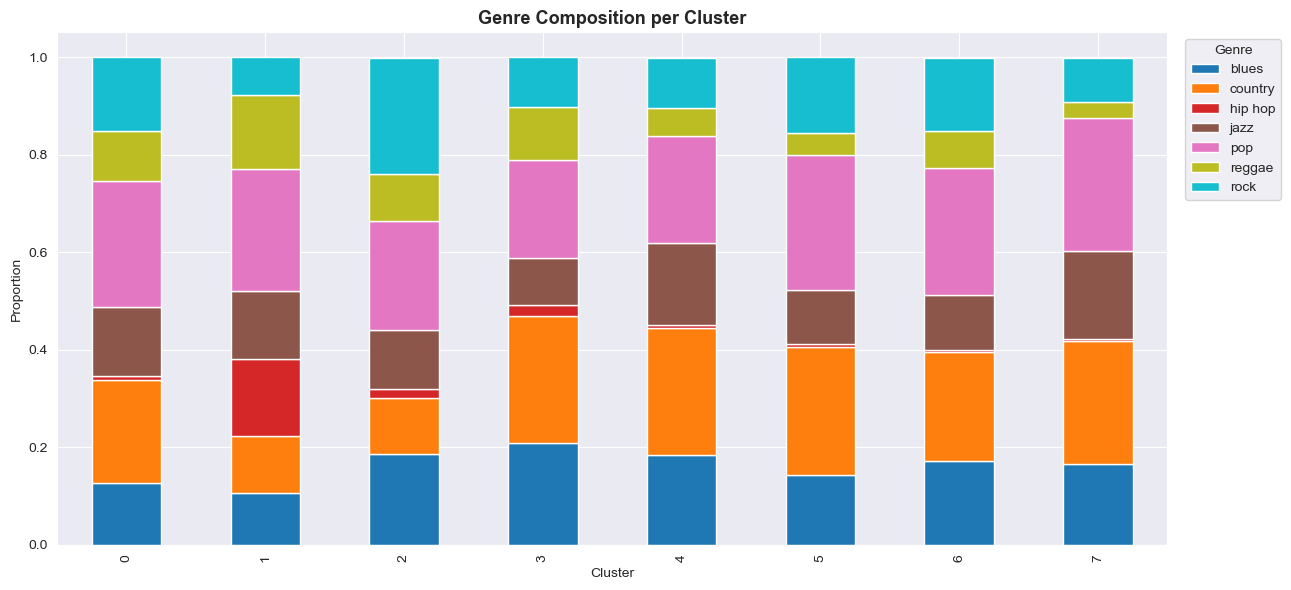

In [9]:
# visualize genre makeup per cluster
cluster_genre.plot(kind='bar', stacked=True, figsize=(13, 6),
                   colormap='tab10', edgecolor='white')
plt.title('Genre Composition per Cluster', fontsize=13, fontweight='bold')
plt.xlabel('Cluster')
plt.ylabel('Proportion')
plt.legend(title='Genre', bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

In [10]:
# save labeled training data
df.to_csv('../data/train_clustered.csv', index=False)
print('Saved train_clustered.csv')

Saved train_clustered.csv


## Test Set Predictions

Now we apply the same preprocessing pipeline to the test dataset and predict cluster labels.

In [11]:
# load raw test data
test_raw = pd.read_csv('../data/test.csv')
print('Test set shape:', test_raw.shape)
test_raw[['artist_name','track_name','genre']]

Test set shape: (10, 25)


,artist_name,track_name,genre
0,godsmack,immune,rock
1,dennis brown,second chance,reggae
2,the black crowes,sister luck,pop
3,jerry lee lewis,your cheating heart,pop
4,paul anka,eso beso,pop
5,noro morales,silencio,jazz
6,rage against the machine,pistol grip pump,rock
7,taste,railway and gun,blues
8,randy travis,messin' with my mind,country
9,paramore,playing god,pop


In [12]:
# the numeric features we trained on
train_feature_cols = ['dating','violence','world/life','night/time','shake the audience',
                      'family/gospel','romantic','communication','obscene','music',
                      'movement/places','light/visual perceptions','family/spiritual',
                      'sadness','feelings','age','len']

# test set has an extra 'like/girls' column — drop it to match training features
test_features = test_raw[train_feature_cols]

# apply the same scaler and PCA from training
scaler_test = StandardScaler()

# re-fit scaler on training data to get same transformation
train_original = pd.read_csv('../data/train.csv')
train_original_clean = train_original.dropna()
scaler_test.fit(train_original_clean[train_feature_cols])

test_scaled = scaler_test.transform(test_features)

# apply PCA with same number of components
n_components = len(feature_cols)
pca_test = PCA(n_components=n_components)
pca_test.fit(scaler_test.transform(train_original_clean[train_feature_cols]))
test_pca = pca_test.transform(test_scaled)

print('Test PCA shape:', test_pca.shape)

Test PCA shape: (10, 14)


In [13]:
# predict clusters on test data using trained KMeans
test_raw['cluster'] = kmeans.predict(test_pca)

print('Test cluster assignments:')
test_raw[['artist_name','track_name','genre','cluster']]

Test cluster assignments:


,artist_name,track_name,genre,cluster
0,godsmack,immune,rock,0
1,dennis brown,second chance,reggae,5
2,the black crowes,sister luck,pop,3
3,jerry lee lewis,your cheating heart,pop,5
4,paul anka,eso beso,pop,5
5,noro morales,silencio,jazz,2
6,rage against the machine,pistol grip pump,rock,1
7,taste,railway and gun,blues,5
8,randy travis,messin' with my mind,country,5
9,paramore,playing god,pop,2


In [14]:
# save test results
test_raw.to_csv('../data/test_clustered.csv', index=False)
print('Saved test_clustered.csv')
print()
print('Cluster breakdown:')
print(test_raw.groupby('cluster')[['artist_name','track_name']].apply(lambda x: x.values.tolist()))

Saved test_clustered.csv

Cluster breakdown:
cluster
0                                 [[godsmack, immune]]
1       [[rage against the machine, pistol grip pump]]
2    [[noro morales, silencio], [paramore, playing ...
3                    [[the black crowes, sister luck]]
5    [[dennis brown, second chance], [jerry lee lew...
dtype: object
